# Balancing & Augmentation Pipeline

**Full pipeline order:**
1. Load with patient IDs — quality check (NaN/Inf + flat leads + missing IDs)
2. Patient-level 80/20 holdout split — test set isolated before anything else
3. On training set only: BWF → 60 Hz Notch → Z-score
4. Gaussian noise copies of positives → concatenate
5. Time shift copies of positives → concatenate
6. Undersample majority to 1:1

Test set receives only preprocessing (no augmentation, no resampling).

## 0. Imports & setup

In [56]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

sys.path.insert(0, "..")
from src.data.dataset import (
    load_seniordesign,
    split_holdout_grouped,
    SD_LEAD_ORDER as LEAD_ORDER,
)
from src.preprocessing.filters import BaselineWanderFilter, NotchFilter
from src.preprocessing.normalization import ZScoreNormalization
from src.preprocessing.augmentation import GaussianNoise, RandomTimeShift
from src.preprocessing.sampling import MajorityUndersampling

RAW_DIR     = "../data/seniordesign_upload"
FS          = 250.0
T_AXIS      = np.arange(2500) / FS
SEED        = 42
GAUSS_SIGMA = 0.02
SHIFT_MAX   = 200    # samples (±0.8 s)
LEAD_II     = LEAD_ORDER.index("II")


def counts(y: np.ndarray, label: str = "") -> str:
    n0, n1 = int((y == 0).sum()), int((y == 1).sum())
    prefix = f"{label:35s}" if label else ""
    return f"{prefix}N={len(y):5d}  neg={n0:5d}  pos={n1:5d}  pos%={100*n1/len(y):.1f}%"


def agg_stats(X: np.ndarray, y: np.ndarray, stage: str) -> dict:
    n0, n1 = int((y == 0).sum()), int((y == 1).sum())
    return {
        "Stage":    stage,
        "N":        len(y),
        "neg":      n0,
        "pos":      n1,
        "pos%":     round(100 * n1 / len(y), 1),
        "RMS":      round(float(np.sqrt((X ** 2).mean())), 4),
        "Std":      round(float(X.std()), 4),
        "HF noise": round(float(np.diff(X, axis=2).std()), 4),
    }

## 1. Load & quality check

In [57]:
X_raw, y_raw, patient_ids = load_seniordesign(RAW_DIR, return_patient_ids=True)
print(counts(y_raw, "Loaded (NaN/Inf already filtered):"))
print(f"Unique patients : {len(np.unique(patient_ids))}")
print(f"Recordings/patient (avg): {len(y_raw)/len(np.unique(patient_ids)):.2f}")

Loaded (NaN/Inf already filtered): N= 2191  neg= 1854  pos=  337  pos%=15.4%
Unique patients : 1386
Recordings/patient (avg): 1.58


In [58]:
# --- Flat-lead check (std < threshold across the whole recording) ---
FLAT_STD_THRESH = 1e-4   # below this → effectively constant signal

lead_std   = X_raw.std(axis=2)         # (N, 12)
flat_mask  = (lead_std < FLAT_STD_THRESH).any(axis=1)  # True = has at least one flat lead
n_flat     = flat_mask.sum()

print(f"Recordings with ≥1 flat lead (std < {FLAT_STD_THRESH}): {n_flat}")

if n_flat > 0:
    flat_leads = (lead_std < FLAT_STD_THRESH)   # (N, 12)
    print("\nFlat-lead counts per lead:")
    for i, lead in enumerate(LEAD_ORDER):
        c = int(flat_leads[:, i].sum())
        if c > 0:
            print(f"  {lead:5s}: {c} recording(s)")

# Remove flat-lead recordings
good_mask   = ~flat_mask
X_raw       = X_raw[good_mask]
y_raw       = y_raw[good_mask]
patient_ids = patient_ids[good_mask]
print(f"\n{counts(y_raw, 'After flat-lead removal:')}")

# --- Missing patient ID check ---
# Some recordings lack Pat_Obfus_MRN; they cannot be patient-split safely.
try:
    nan_mask = np.isnan(patient_ids.astype(float))
except (ValueError, TypeError):
    nan_mask = np.array([str(p).strip() in ("", "nan", "None") for p in patient_ids])

n_missing_id = int(nan_mask.sum())
print(f"Recordings with missing patient ID: {n_missing_id}")
if n_missing_id > 0:
    X_raw       = X_raw[~nan_mask]
    y_raw       = y_raw[~nan_mask]
    patient_ids = patient_ids[~nan_mask]
    print(f"{counts(y_raw, 'After missing-ID removal:')}")

Recordings with ≥1 flat lead (std < 0.0001): 8

Flat-lead counts per lead:
  V3   : 1 recording(s)
  V4   : 2 recording(s)
  V5   : 2 recording(s)
  V6   : 3 recording(s)

After flat-lead removal:           N= 2183  neg= 1848  pos=  335  pos%=15.3%
Recordings with missing patient ID: 5
After missing-ID removal:          N= 2178  neg= 1843  pos=  335  pos%=15.4%


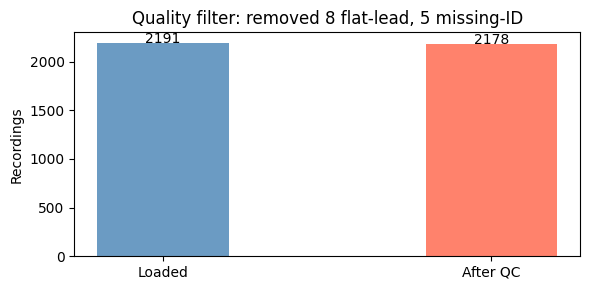

In [59]:
# --- Quality summary bar chart ---
fig, ax = plt.subplots(figsize=(6, 3))
n_loaded = len(y_raw) + n_flat + n_missing_id
ax.bar(["Loaded", "After QC"],
       [n_loaded, len(y_raw)],
       color=["steelblue", "tomato"], alpha=0.8, width=0.4)
ax.set_ylabel("Recordings")
ax.set_title(f"Quality filter: removed {n_flat} flat-lead, {n_missing_id} missing-ID")
for xi, val in enumerate([n_loaded, len(y_raw)]):
    ax.text(xi, val + 2, str(val), ha="center", fontsize=10)
plt.tight_layout(); plt.show()

## 2. Patient-level holdout split

Split **before any preprocessing, augmentation, or balancing**.
No patient appears on both sides — prevents the model from memorising patient-specific ECG patterns.

In [60]:
(
    X_dev,  X_test,
    y_dev,  y_test,
    g_dev,  g_test,
) = split_holdout_grouped(X_raw, y_raw, patient_ids, test_size=0.20, seed=SEED)

# Verify no patient leakage
shared = set(g_dev) & set(g_test)
assert len(shared) == 0, f"Patient leakage: {len(shared)} shared IDs!"

print(counts(y_dev,  "Dev  set:"))
print(counts(y_test, "Test set:"))
print(f"\nDev  patients : {len(np.unique(g_dev))}")
print(f"Test patients : {len(np.unique(g_test))}")
print(f"Shared patients: {len(shared)}  ← must be 0")

Dev  set:                          N= 1747  neg= 1470  pos=  277  pos%=15.9%
Test set:                          N=  431  neg=  373  pos=   58  pos%=13.5%

Dev  patients : 1106
Test patients : 277
Shared patients: 0  ← must be 0


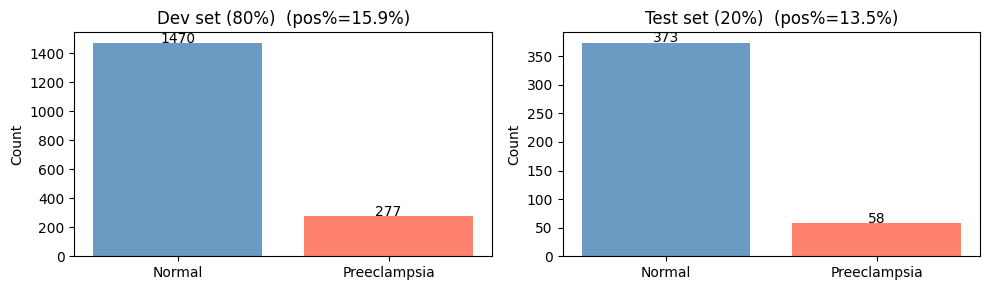

In [61]:
# Visualise split
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (ys, title, colors) in zip(axes, [
    (y_dev,  "Dev set (80%)",  ["steelblue", "tomato"]),
    (y_test, "Test set (20%)", ["steelblue", "tomato"]),
]):
    n0, n1 = int((ys == 0).sum()), int((ys == 1).sum())
    bars = ax.bar(["Normal", "Preeclampsia"], [n0, n1], color=colors, alpha=0.8)
    for bar, val in zip(bars, [n0, n1]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1, str(val), ha="center", fontsize=10)
    ax.set_title(f"{title}  (pos%={100*n1/len(ys):.1f}%)")
    ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

## 3. Preprocessing — dev set only

BWF → 60 Hz Notch → Z-score.
Test set is preprocessed separately (same steps, no augmentation or resampling).

In [62]:
def preprocess(X: np.ndarray) -> np.ndarray:
    X, _ = BaselineWanderFilter(cutoff=0.5, order=4, fs=FS).transform(X.copy())
    X, _ = NotchFilter(freq=60.0, Q=30.0, fs=FS).transform(X)
    X, _ = ZScoreNormalization(per_lead=True).transform(X)
    return X


X_dev_proc  = preprocess(X_dev)
X_test_proc = preprocess(X_test)   # preprocessed but otherwise untouched

print(counts(y_dev,  "Dev (preprocessed) :"))
print(counts(y_test, "Test (preprocessed):"))
print(f"\nZ-score check on dev — first sample, leads 0-2:")
print(f"  mean : {X_dev_proc[0].mean(axis=1)[:3].round(4)}")
print(f"  std  : {X_dev_proc[0].std(axis=1)[:3].round(4)}")

stats_log = [agg_stats(X_dev_proc, y_dev, "1. Dev — preprocessed")]

Dev (preprocessed) :               N= 1747  neg= 1470  pos=  277  pos%=15.9%
Test (preprocessed):               N=  431  neg=  373  pos=   58  pos%=13.5%

Z-score check on dev — first sample, leads 0-2:
  mean : [-0. -0.  0.]
  std  : [1. 1. 1.]


### 3a. Filter effects — PSD on Lead II (dev set)

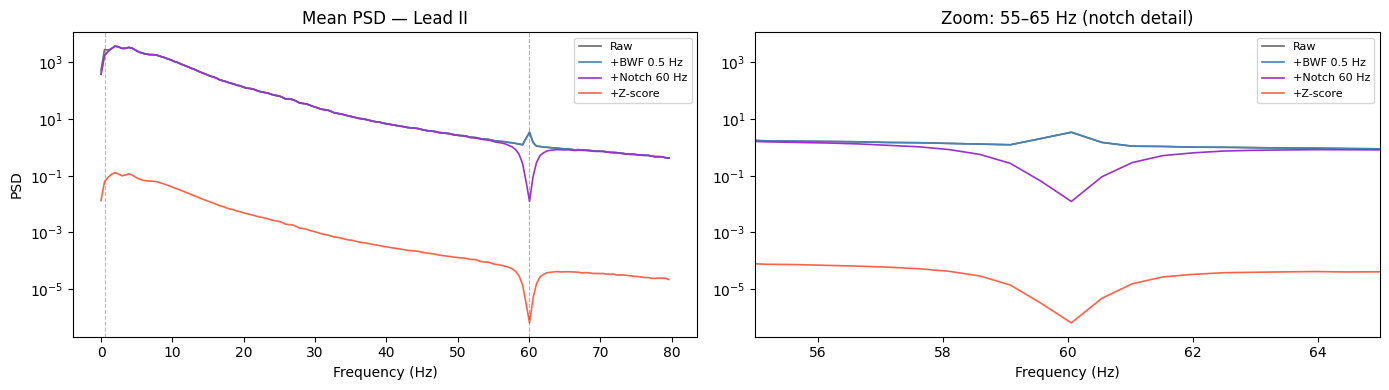

In [63]:
def mean_psd(X_arr, lead_i, nperseg=512):
    psds = [welch(sig, fs=FS, nperseg=nperseg)[1] for sig in X_arr[:, lead_i, :]]
    f    = welch(X_arr[0, lead_i], fs=FS, nperseg=nperseg)[0]
    return f, np.stack(psds).mean(axis=0)


X_dev_bwf,  _ = BaselineWanderFilter(cutoff=0.5, order=4, fs=FS).transform(X_dev.copy())
X_dev_notch, _ = NotchFilter(freq=60.0, Q=30.0, fs=FS).transform(X_dev_bwf.copy())

stages_psd = [
    ("Raw",           X_dev,       "dimgray"),
    ("+BWF 0.5 Hz",   X_dev_bwf,   "steelblue"),
    ("+Notch 60 Hz",  X_dev_notch, "darkorchid"),
    ("+Z-score",      X_dev_proc,  "tomato"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, Xs, color in stages_psd:
    f, psd = mean_psd(Xs, LEAD_II)
    mask = f <= 80
    axes[0].semilogy(f[mask], psd[mask], lw=1.2, color=color, label=name)
    axes[1].semilogy(f[mask], psd[mask], lw=1.2, color=color, label=name)

axes[0].axvline(0.5,  color="steelblue",  lw=0.8, linestyle="--", alpha=0.5)
axes[0].axvline(60.0, color="darkorchid", lw=0.8, linestyle="--", alpha=0.5)
axes[0].set_title("Mean PSD — Lead II"); axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("PSD"); axes[0].legend(fontsize=8)
axes[1].set_xlim(55, 65); axes[1].set_title("Zoom: 55–65 Hz (notch detail)")
axes[1].set_xlabel("Frequency (Hz)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Augmentation — minority (positives) only, each step adds copies

Negatives are left untouched and will be undersampled to match.
Positives get Gaussian and TimeShift copies appended (3× minority diversity).

In [64]:
# Split dev into positives (minority) and negatives (majority)
pos_mask = (y_dev == 1)
X_pos    = X_dev_proc[pos_mask]
X_neg    = X_dev_proc[~pos_mask]
n_pos    = len(X_pos)
n_neg    = len(X_neg)

# Augment positives only — Gaussian noise copy
X_pos_g, _ = GaussianNoise(sigma=GAUSS_SIGMA).transform(X_pos.copy())

X_after_g = np.concatenate([X_neg, X_pos, X_pos_g], axis=0)
y_after_g = np.concatenate([
    np.zeros(n_neg, dtype=y_dev.dtype),
    np.ones(n_pos,  dtype=y_dev.dtype),
    np.ones(n_pos,  dtype=y_dev.dtype),
], axis=0)
print(counts(y_after_g, "After Gaussian on positives:"))
stats_log.append(agg_stats(X_after_g, y_after_g, "2. + Gaussian on pos"))

# Augment positives only — TimeShift copy
X_pos_t, _ = RandomTimeShift(max_shift=SHIFT_MAX).transform(X_pos.copy())

X_aug = np.concatenate([X_neg, X_pos, X_pos_g, X_pos_t], axis=0)
y_aug = np.concatenate([
    np.zeros(n_neg, dtype=y_dev.dtype),
    np.ones(n_pos,  dtype=y_dev.dtype),
    np.ones(n_pos,  dtype=y_dev.dtype),
    np.ones(n_pos,  dtype=y_dev.dtype),
], axis=0)
print(counts(y_aug, "After TimeShift on positives:"))
stats_log.append(agg_stats(X_aug, y_aug, "3. + TimeShift on pos"))

After Gaussian on positives:       N= 2024  neg= 1470  pos=  554  pos%=27.4%
After TimeShift on positives:      N= 2301  neg= 1470  pos=  831  pos%=36.1%


### 4a. Augmented copies — Lead II, one preeclampsia sample

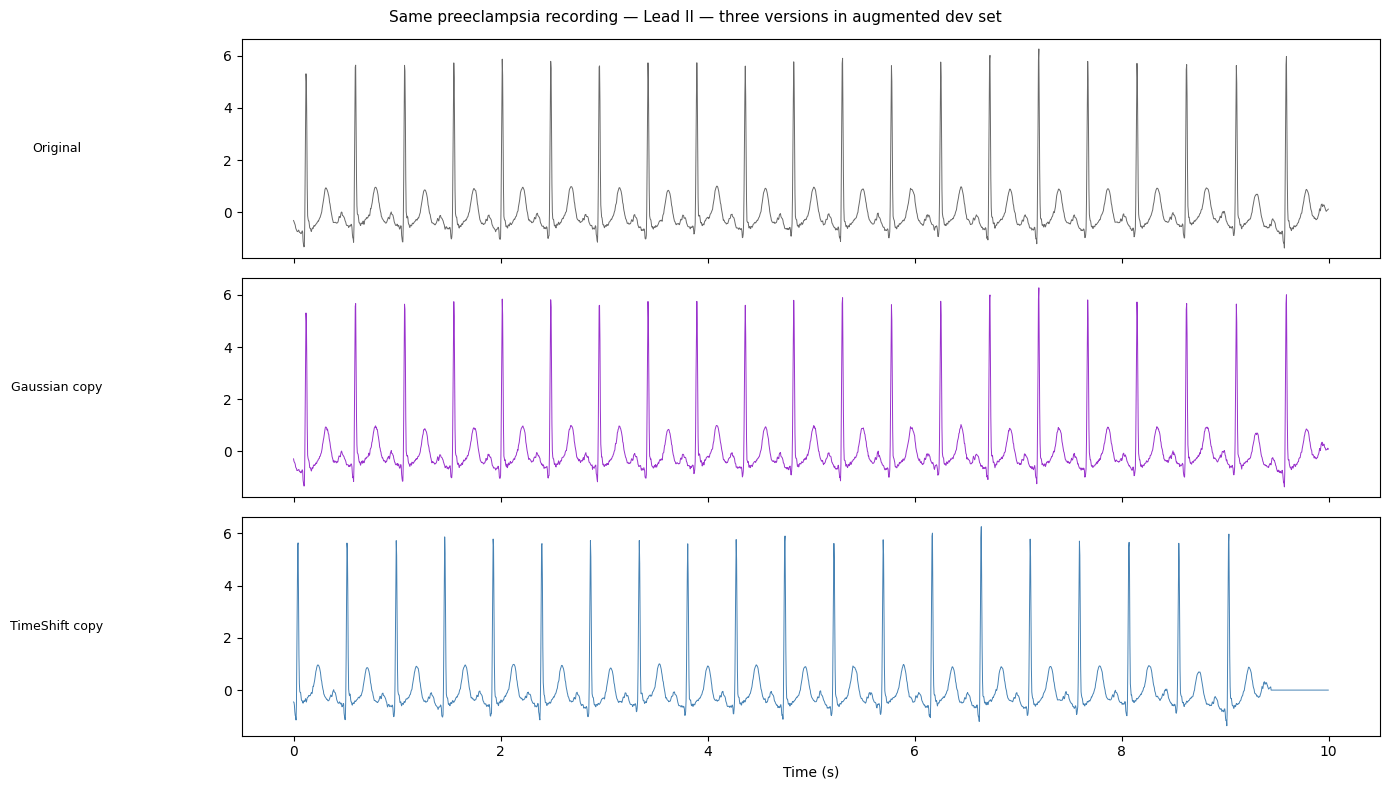

In [65]:
# Layout of X_aug: [n_neg negatives | n_pos originals | n_pos gaussian | n_pos timeshift]
vis_i = 0   # first positive in each block

variants = [
    ("Original",       X_aug[n_neg + vis_i],            "dimgray"),
    ("Gaussian copy",  X_aug[n_neg + n_pos + vis_i],     "darkorchid"),
    ("TimeShift copy", X_aug[n_neg + 2 * n_pos + vis_i], "steelblue"),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Same preeclampsia recording — Lead II — three versions in augmented dev set", fontsize=11)
for ax, (name, sample, color) in zip(axes, variants):
    ax.plot(T_AXIS, sample[LEAD_II], lw=0.7, color=color)
    ax.set_ylabel(name, fontsize=9, rotation=0, labelpad=120, va="center")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout(); plt.show()

## 5. Undersample to 1:1 balance

In [66]:
X_train, y_train = MajorityUndersampling(ratio=1.0, seed=SEED).transform(X_aug, y_aug)

print(counts(y_train, "Training set (final):"))
print(counts(y_test,  "Test set (untouched): "))
stats_log.append(agg_stats(X_train, y_train, "4. Training — undersampled"))

Training set (final):              N= 1662  neg=  831  pos=  831  pos%=50.0%
Test set (untouched):              N=  431  neg=  373  pos=   58  pos%=13.5%


## 6. Class counts through the pipeline

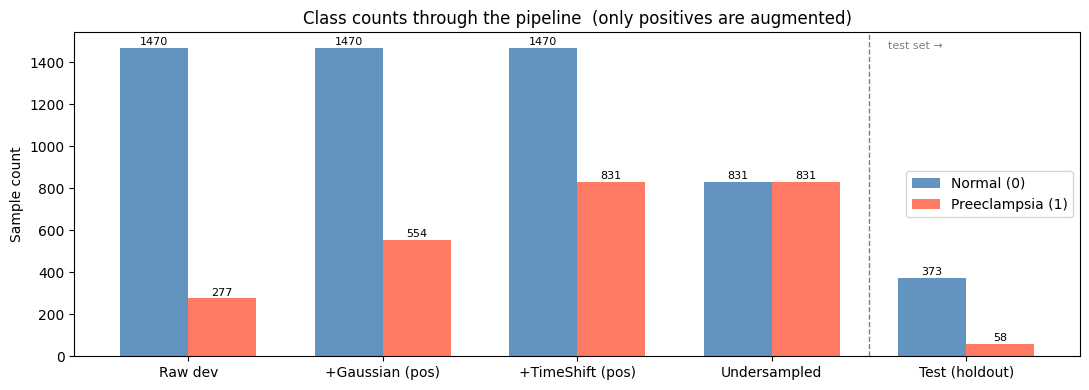

In [67]:
stage_counts = [
    ("Raw dev",             n_neg, n_pos),
    ("+Gaussian (pos)",     n_neg, 2 * n_pos),
    ("+TimeShift (pos)",    n_neg, 3 * n_pos),
    ("Undersampled",        int((y_train == 0).sum()), int((y_train == 1).sum())),
    ("Test (holdout)",      int((y_test == 0).sum()),  int((y_test == 1).sum())),
]

x = np.arange(len(stage_counts))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 4))
neg_vals = [s[1] for s in stage_counts]
pos_vals = [s[2] for s in stage_counts]
ax.bar(x - w/2, neg_vals, w, label="Normal (0)",       color="steelblue", alpha=0.85)
ax.bar(x + w/2, pos_vals, w, label="Preeclampsia (1)", color="tomato",    alpha=0.85)
for xi, (n, p) in zip(x, zip(neg_vals, pos_vals)):
    ax.text(xi - w/2, n + 3, str(n), ha="center", va="bottom", fontsize=8)
    ax.text(xi + w/2, p + 3, str(p), ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([s[0] for s in stage_counts])
ax.set_ylabel("Sample count")
ax.set_title("Class counts through the pipeline  (only positives are augmented)")
ax.legend()
ax.axvline(3.5, color="gray", lw=1, linestyle="--")
ax.text(3.6, ax.get_ylim()[1] * 0.95, "test set →", fontsize=8, color="gray")
plt.tight_layout(); plt.show()

## 7. Peak amplitude distribution — training vs test

After per-lead z-score, every recording has std=1, so per-sample RMS is constant ≈ 1.
**Peak |x|** still varies: recordings with sharper QRS complexes have higher peak-to-baseline ratios.

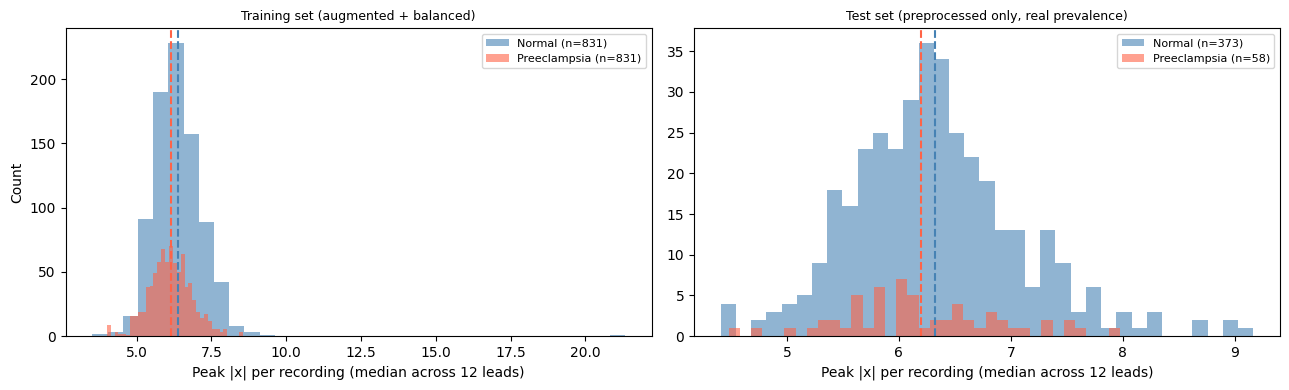

In [68]:
def per_sample_peak(X: np.ndarray) -> np.ndarray:
    """Max absolute amplitude per recording (proxy for QRS sharpness post z-score).
    Median across leads avoids a single outlier lead dominating the metric."""
    return np.median(np.abs(X).max(axis=2), axis=1)   # (N,)


def safe_hist(ax, vals, label, color):
    """Histogram that survives zero-range / single-value inputs."""
    if vals.size == 0:
        return
    lo, hi = float(vals.min()), float(vals.max())
    if hi - lo < 1e-9:                # constant data — render as a spike
        ax.axvline(lo, color=color, lw=2, label=f"{label} (constant {lo:.3f})")
        return
    ax.hist(vals, bins=35, range=(lo, hi), color=color, alpha=0.6, label=label)


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (Xs, ys, title) in zip(axes, [
    (X_train,     y_train, "Training set (augmented + balanced)"),
    (X_test_proc, y_test,  "Test set (preprocessed only, real prevalence)"),
]):
    peak_neg = per_sample_peak(Xs[ys == 0])
    peak_pos = per_sample_peak(Xs[ys == 1])
    safe_hist(ax, peak_neg, f"Normal (n={len(peak_neg)})",        "steelblue")
    safe_hist(ax, peak_pos, f"Preeclampsia (n={len(peak_pos)})",  "tomato")
    if peak_neg.size: ax.axvline(peak_neg.mean(), color="steelblue", lw=1.5, linestyle="--")
    if peak_pos.size: ax.axvline(peak_pos.mean(), color="tomato",    lw=1.5, linestyle="--")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Peak |x| per recording (median across 12 leads)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Count")
plt.tight_layout(); plt.show()

## 8. Aggregate stats — all training pipeline stages

                     Stage    N  neg  pos  pos%    RMS    Std  HF noise
     1. Dev — preprocessed 1747 1470  277  15.9 1.0000 1.0000    0.2403
      2. + Gaussian on pos 2024 1470  554  27.4 1.0000 1.0000    0.2412
     3. + TimeShift on pos 2301 1470  831  36.1 0.9974 0.9974    0.2411
4. Training — undersampled 1662  831  831  50.0 0.9964 0.9964    0.2410


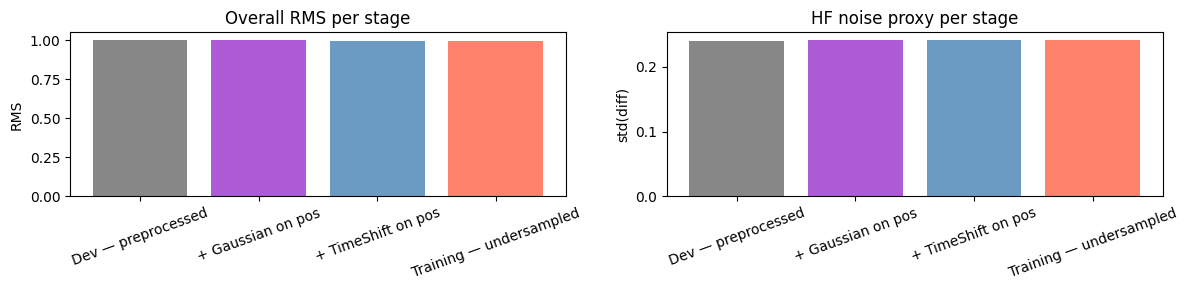

In [69]:
summary = pd.DataFrame(stats_log)
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
colors_bar = ["dimgray", "darkorchid", "steelblue", "tomato"]
labels = [s.split(".", 1)[-1].strip() for s in summary["Stage"]]

axes[0].bar(labels, summary["RMS"],      color=colors_bar, alpha=0.8)
axes[0].set_title("Overall RMS per stage"); axes[0].set_ylabel("RMS")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(labels, summary["HF noise"], color=colors_bar, alpha=0.8)
axes[1].set_title("HF noise proxy per stage"); axes[1].set_ylabel("std(diff)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

## 9. Pipeline summary

```
Raw data (with patient IDs)
  ↓ Quality check: drop NaN/Inf + flat leads (std < 1e-4) + missing patient IDs
  ↓ Patient-level 80/20 holdout split  ← NO patient appears on both sides
  │
  ├─ TEST SET  → BWF + Notch + Z-score only. Real prevalence preserved. Set aside.
  │
  └─ DEV SET  (training pipeline below)
       ↓ BWF (0.5 Hz high-pass)
       ↓ NotchFilter (60 Hz, Q=30)
       ↓ ZScoreNormalization (per-lead)
       ↓ Split into negatives (untouched) and positives (minority)
       ↓ GaussianNoise(sigma=0.02) on positives → concat   (2x positives)
       ↓ RandomTimeShift(±200 samp) on positives → concat   (3x positives)
       ↓ MajorityUndersampling (1:1)  — drop excess negatives to match 3x positives
       =  TRAINING SET (1:1, with 3x minority diversity)
```

**Why augment positives only?** Goal is to give the minority class more diversity. Augmenting negatives just to throw them away in the undersample step is wasted compute and dilutes per-original-sample diversity in the kept set.

**For cross-validation:** apply the dev-set pipeline (steps 3–6) inside each fold, not once up-front.
Use `kfold_cv_indices_grouped` so patients stay within a single fold.
